#Домашня робота №2
##ФБ-42 Кисельова Єлизавета

In [1]:
# Імпорт основних бібліотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

plt.style.use('seaborn-v0_8')
%matplotlib inline

In [2]:
#Завантаження датасету
df = pd.read_csv('global_tech_startups_2026.csv')
df.head()

,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status
0,B730AD52,HealthTech,2014,Canada,Montreal,Seed,1.64,17.81,1.46,0.33,3.8,23,0,23,Tier 3 (Angel/Seed),High,Independent
1,65A5F690,Web3/Crypto,2014,China,Beijing,Pre-IPO,103.87,949.16,32.77,2.42,41.2,242,146,96,Tier 3 (Angel/Seed),NaN,Closed
2,F106C853,Cybersecurity,2020,USA,San Francisco,Series A,10.08,43.37,2.16,1.01,9.1,59,0,59,Tier 2 (Mid-size VC),High,Independent
3,2BD798AF,FinTech,2023,India,Delhi NCR,Series B,32.28,257.62,11.66,0.78,36.7,76,0,76,Tier 3 (Angel/Seed),Medium,Independent
4,C5CB4451,Generative AI,2020,USA,New York,Series C+,13.41,76.73,2.57,1.12,11.0,59,28,31,Tier 2 (Mid-size VC),Medium,Closed


In [3]:
numeric_df = df.select_dtypes(include=[np.number])
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

df_no_outliers = df[~((numeric_df < (Q1 - 1.5 * IQR)) |
                      (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]
numeric_df = df_no_outliers.select_dtypes(include=[np.number])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)
X_scaled.shape

(18729, 9)

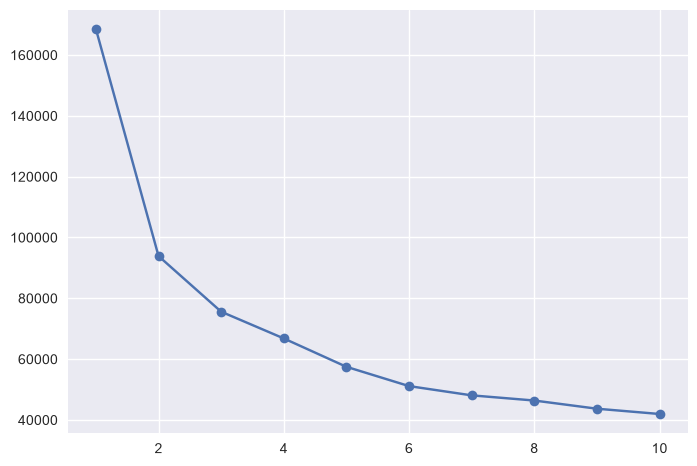

In [4]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.grid(True)
plt.show()


In [5]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans.fit_predict(X_scaled)

df_no_outliers['cluster_kmeans'] = labels
df_no_outliers['cluster_kmeans'].value_counts()

cluster_kmeans
0    12259
2     4644
1     1826
Name: count, dtype: int64

In [6]:
centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)

cluster_centers_df = pd.DataFrame(centers, columns=numeric_df.columns)
cluster_centers_df['cluster_size'] = df_no_outliers['cluster_kmeans'].value_counts().sort_index().values

cluster_centers_df

,Founding_Year,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,cluster_size
0,2018.924676,2.718100,33.166828,2.305640,0.485723,4.841828,32.153827,6.497106,25.656721,12259
1,2018.806469,40.322368,296.990269,18.443317,2.331996,17.564200,157.052083,5.896930,151.155154,1826
2,2019.130875,14.927245,124.472587,8.969004,0.773607,18.228870,52.514446,4.001078,48.513368,4644


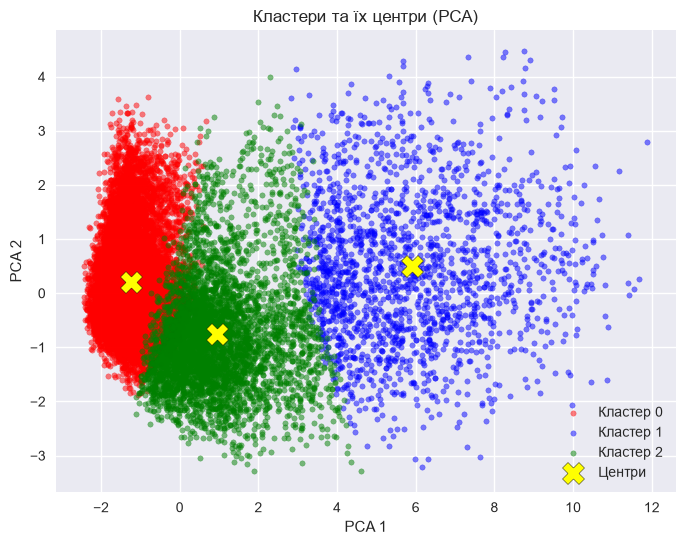

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

labels = df_no_outliers['cluster_kmeans']

#центри кластерів у PCA-просторі
centers_pca = pca.transform(kmeans.cluster_centers_)

#кольори 
colors = ['red', 'blue', 'green']

plt.figure(figsize=(8,6))

#малюю кластери
for cid in range(3):
    plt.scatter(
        X_pca[labels == cid, 0],
        X_pca[labels == cid, 1],
        s=15,
        color=colors[cid],
        alpha=0.5,
        label=f'Кластер {cid}'
    )

#малюю центри
plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    s=250,
    color='yellow',
    edgecolor='black',
    marker='X',
    label='Центри'
)

plt.title('Кластери та їх центри (PCA)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
from sklearn.metrics import pairwise_distances

radii = []

for cluster_id in range(3):
    cluster_points = X_scaled[labels == cluster_id]
    center = centers_scaled[cluster_id].reshape(1, -1)
    distances = pairwise_distances(cluster_points, center, metric='euclidean')
    radius = np.mean(distances)
    radii.append(radius)

radii

[np.float64(1.541205236653476),
 np.float64(3.23192785016058),
 np.float64(2.007785385938936)]

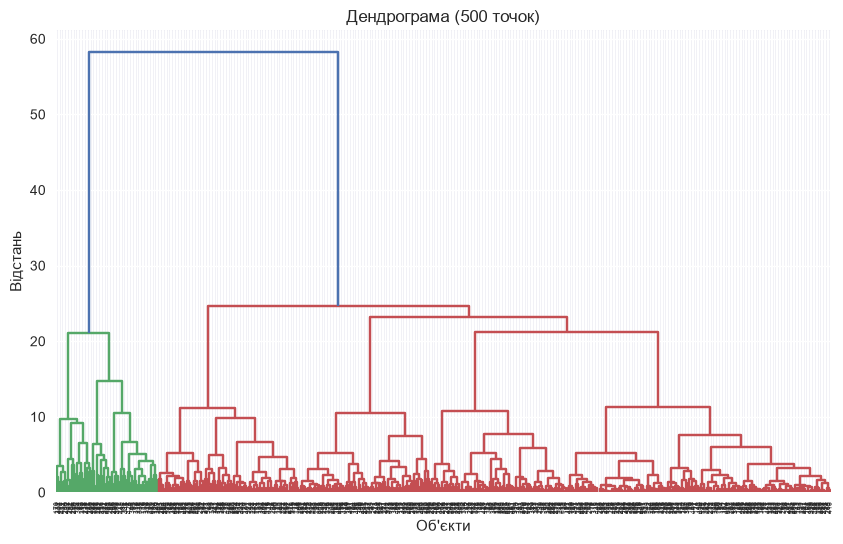

In [10]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
X_small = X_scaled[:500]

Z_small = linkage(X_small, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(Z_small)
plt.title('Дендрограма (500 точок)')
plt.xlabel('Об\'єкти')
plt.ylabel('Відстань')
plt.show()


In [14]:
df_no_outliers['cluster_hier'].value_counts().sort_index()

cluster_hier
1     2648
2     4098
3    11983
Name: count, dtype: int64